# 01 - Exploratory analysis: GoEmotions

**Status:** early-stage exploration. No modelling or findings are claimed here.

**Aim:** understand the structure of the dataset (size, labels, text length, vocabulary) before any modelling, and note limitations early.

See `DATASET_PLAN.md` for why this dataset was chosen and the ethics notes.

In [1]:
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

pd.set_option("display.max_colwidth", 120)

## 1. Load the dataset

In [2]:
ds = load_dataset("google-research-datasets/go_emotions", "simplified")
print(ds)

label_names = ds["train"].features["labels"].feature.names
print(len(label_names), "labels:", label_names)

README.md:   0%|          | 0.00/9.40k [00:00<?, ?B/s]

simplified/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 2.77MB            

simplified/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

simplified/validation-00000-of-00001.par(…): reconstructing file:   0%|          |  0.00B /  350kB            

simplified/validation-00000-of-00001.par(…): downloading bytes:           |  0.00B            

...

simplified/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})
28 labels: ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


## 2. Split sizes

In [3]:
for split in ds:
    print(split, len(ds[split]))

train 43410
validation 5426
test 5427


## 3. Label distribution

Each comment can have more than one label, so counts below are label occurrences, not comments.

,count
neutral,14219
admiration,4130
approval,2939
gratitude,2662
annoyance,2470
amusement,2328
curiosity,2191
love,2086
disapproval,2022
optimism,1581


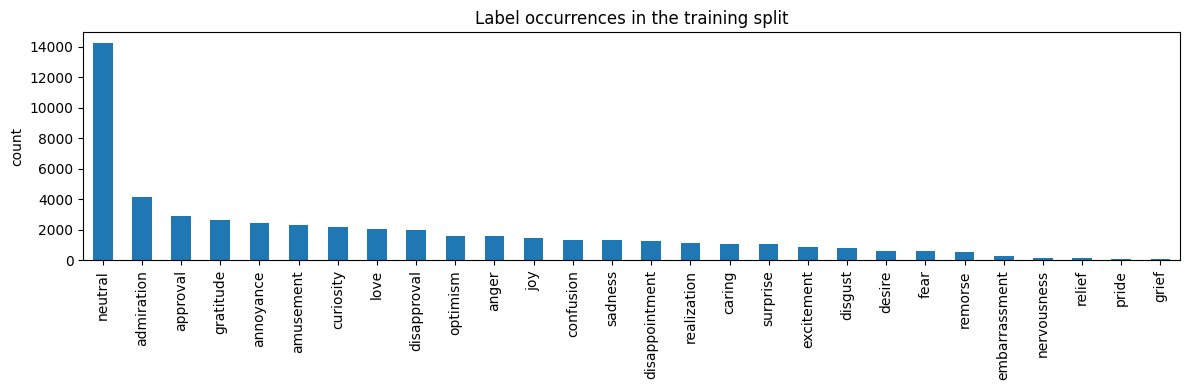

In [4]:
train = ds["train"].to_pandas()

label_counts = Counter(l for labels in train["labels"] for l in labels)
dist = (
    pd.Series({label_names[i]: c for i, c in label_counts.items()})
    .sort_values(ascending=False)
)
display(dist.to_frame("count"))

dist.plot(kind="bar", figsize=(12, 4), title="Label occurrences in the training split")
plt.ylabel("count")
plt.tight_layout()
plt.show()

## 4. Labels per comment

In [5]:
train["n_labels"] = train["labels"].apply(len)
print(train["n_labels"].value_counts().sort_index())

n_labels
1    36308
2     6541
3      532
4       28
5        1
Name: count, dtype: int64


## 5. Text length

count    43410.000000
mean        12.840175
std          6.701597
min          1.000000
25%          7.000000
50%         12.000000
75%         18.000000
max         33.000000
Name: n_words, dtype: float64


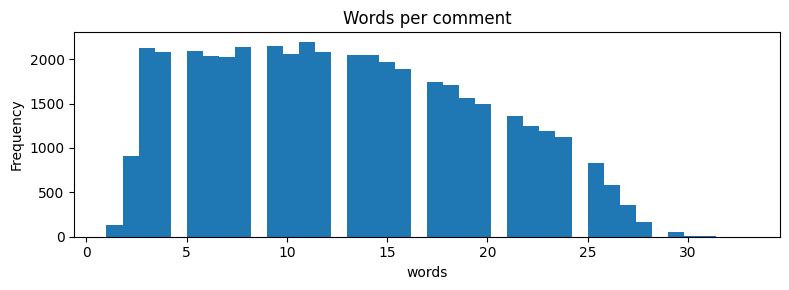

In [6]:
train["n_words"] = train["text"].str.split().str.len()
print(train["n_words"].describe())

train["n_words"].plot(kind="hist", bins=40, figsize=(8, 3), title="Words per comment")
plt.xlabel("words")
plt.tight_layout()
plt.show()

## 6. Most frequent words (simple tokenisation, no stop-word removal yet)

In [7]:
tokens = Counter(
    w for t in train["text"].str.lower()
    for w in re.findall(r"[a-z']+", t)
)
pd.DataFrame(tokens.most_common(25), columns=["word", "count"])

,word,count
0,the,18000
1,i,17719
2,to,12600
3,a,12361
4,you,10403
5,and,9037
6,it,8614
7,that,8595
8,is,8472
9,name,7905


## 7. A few examples

A small number of examples only, to check that labels look sensible. Do not copy examples into reports without checking they contain no personal details.

In [8]:
sample = train.sample(5, random_state=0)
for _, row in sample.iterrows():
    names = [label_names[i] for i in row["labels"]]
    print(names, "->", row["text"], "\n")

['approval', 'confusion'] -> Apparently young children have to figure out breathing through their mouth. I forget at what age that typically occurs, but yeah... 

['approval'] -> I think we can all agree that this is the right answer. 

['neutral'] -> Indeed. Ex-NY area cop here, similar to dirtbag, shitbird, and fuckstick, but more acceptable for TV. 

['nervousness'] -> I told their kid that it was okay to be upset. (He was anxious and I was validating his feelings.) 

['disgust'] -> I was skeptical about it being huge but damn.. 



## 8. Notes and limitations.

### Exploratory Observations & Limitations

1. **Class Distribution & Imbalance:**
   - A substantial proportion of the dataset is dominated by `neutral`, followed by positive social acknowledgments like `admiration` and `approval`.
   - Subtle emotional states and nuanced negative classes have markedly fewer samples, indicating that standard loss functions or unweighted baselines may struggle with minority classes.

2. **Linguistic Structure & Token Dynamics:**
   - Text instances are short, informal Reddit comments (averaging ~12–15 tokens per sample).
   - As expected before stop-word removal, frequency distributions are heavily skewed toward high-utility syntactic words (e.g., pronouns, auxiliary verbs, and prepositions).
   - Once common stop words are isolated, the vocabulary concentrates around explicit conversational markers rather than extended reflective narratives.

3. **Methodological Takeaways for Baseline Modeling:**
   - Short sentence lengths mean n-gram overlaps will be sparse; TF-IDF representations must account for sub-linear term frequency scaling and appropriate n-gram ranges.
   - Evaluation metrics must rely on macro- and micro-averaged F1 rather than raw accuracy due to the evident label distribution skew.